In [1]:
import pandas as pd
import textstat
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [ ]:
DATA_PATH = "../data/processed/arxiv_2010_2018_clean_citations.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset size:", len(df))

df.head()

Dataset size: 2272


,paper_id,title,field,abstract,published,year,arxiv_id_full,citation_count
0,http://arxiv.org/abs/1901.00064v3,Impossibility and Uncertainty Theorems in AI V...,computer_science,Utility functions or their equivalents (value ...,2018-12-31 23:51:27+00:00,2018,1901.00064,54
1,http://arxiv.org/abs/1901.00063v2,Extreme Relative Pose Estimation for RGB-D Sca...,computer_science,Estimating the relative rigid pose between two...,2018-12-31 23:43:16+00:00,2018,1901.00063,60
2,http://arxiv.org/abs/1901.00062v3,Deep Frame Prediction for Video Coding,computer_science,We propose a novel frame prediction method usi...,2018-12-31 23:41:50+00:00,2018,1901.00062,66
3,http://arxiv.org/abs/1901.00059v2,Determining Principal Component Cardinality th...,computer_science,PCA (Principal Component Analysis) and its var...,2018-12-31 22:41:32+00:00,2018,1901.00059,0
4,http://arxiv.org/abs/1901.00056v2,Entity Synonym Discovery via Multipiece Bilate...,computer_science,Being able to automatically discover synonymou...,2018-12-31 22:05:05+00:00,2018,1901.00056,16


In [5]:
df = df.dropna(subset=["abstract"])

print("Dataset size after removing rows with no abstracts:", len(df))
#No missing abstracts

Dataset size after removing rows with no abstracts: 2272


In [6]:
df["flesch_reading_ease"] = df["abstract"].apply(textstat.flesch_reading_ease)
df["flesch_kincaid_grade"] = df["abstract"].apply(textstat.flesch_kincaid_grade)
df["gunning_fog"] = df["abstract"].apply(textstat.gunning_fog)
df["smog_index"] = df["abstract"].apply(textstat.smog_index)

df.head()

,paper_id,title,field,abstract,published,year,arxiv_id_full,citation_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index
0,http://arxiv.org/abs/1901.00064v3,Impossibility and Uncertainty Theorems in AI V...,computer_science,Utility functions or their equivalents (value ...,2018-12-31 23:51:27+00:00,2018,1901.00064,54,9.464828,20.172783,23.084729,19.430817
1,http://arxiv.org/abs/1901.00063v2,Extreme Relative Pose Estimation for RGB-D Sca...,computer_science,Estimating the relative rigid pose between two...,2018-12-31 23:43:16+00:00,2018,1901.00063,60,16.174642,16.375542,20.441908,17.693802
2,http://arxiv.org/abs/1901.00062v3,Deep Frame Prediction for Video Coding,computer_science,We propose a novel frame prediction method usi...,2018-12-31 23:41:50+00:00,2018,1901.00062,66,36.931731,12.952436,15.594872,14.554593
3,http://arxiv.org/abs/1901.00059v2,Determining Principal Component Cardinality th...,computer_science,PCA (Principal Component Analysis) and its var...,2018-12-31 22:41:32+00:00,2018,1901.00059,0,8.085000,16.603333,22.755556,18.458007
4,http://arxiv.org/abs/1901.00056v2,Entity Synonym Discovery via Multipiece Bilate...,computer_science,Being able to automatically discover synonymou...,2018-12-31 22:05:05+00:00,2018,1901.00056,16,20.370574,16.535577,20.002284,17.553077


In [7]:
summary = df.groupby("field")[[
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "gunning_fog",
    "smog_index"
]].agg(["mean", "median", "std"])

summary

flesch_reading_ease                        \
                                mean     median        std   
field                                                        
computer_science           23.338486  23.071124  12.691292   
mathematics                29.255850  28.503200  16.400530   
physics                    19.890337  20.433105  13.531055   

                 flesch_kincaid_grade                      gunning_fog  \
                                 mean     median       std        mean   
field                                                                    
computer_science            15.653718  15.514161  2.418885   18.717945   
mathematics                 15.028519  14.924824  3.222296   18.582860   
physics                     16.527646  16.449378  2.813283   20.236244   

                                      smog_index                       
                     median       std       mean     median       std  
field                                                                  
computer_science  18.565979  2.750269  16.574066  16.526678  1.961427  
mathematics       18.634599  3.637197  16.332112  16.404323  2.599354  
physics           20.145360  3.170041  17.613229  17.505863  2.220643

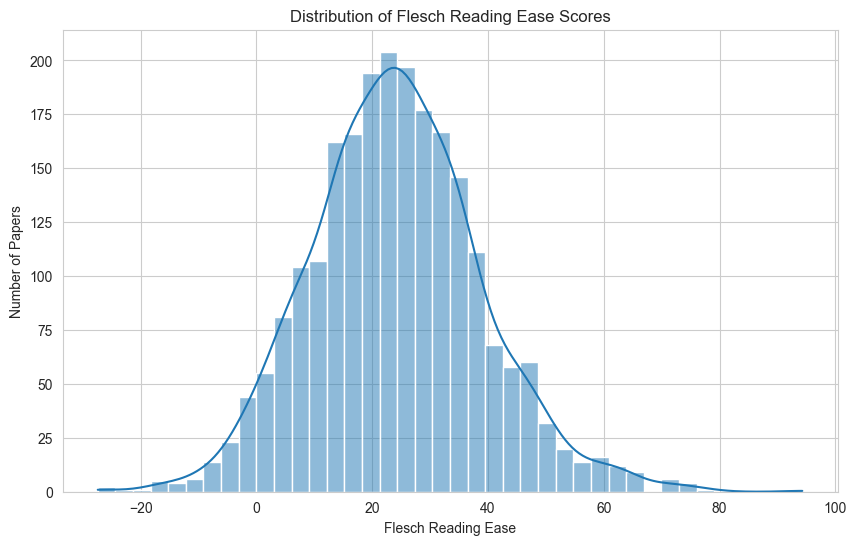

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df["flesch_reading_ease"], bins=40, kde=True)

plt.title("Distribution of Flesch Reading Ease Scores")
plt.xlabel("Flesch Reading Ease")
plt.ylabel("Number of Papers")

plt.show()

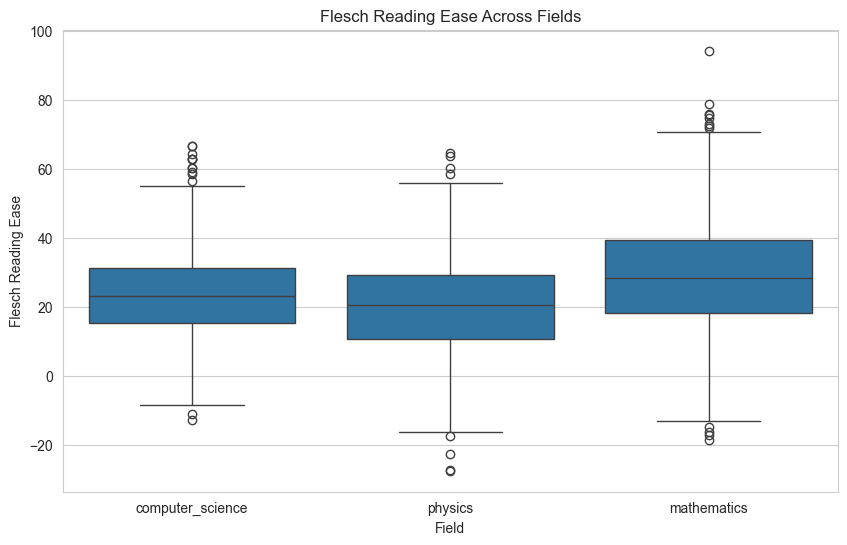

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="field", y="flesch_reading_ease")

plt.title("Flesch Reading Ease Across Fields")
plt.xlabel("Field")
plt.ylabel("Flesch Reading Ease")

plt.show()

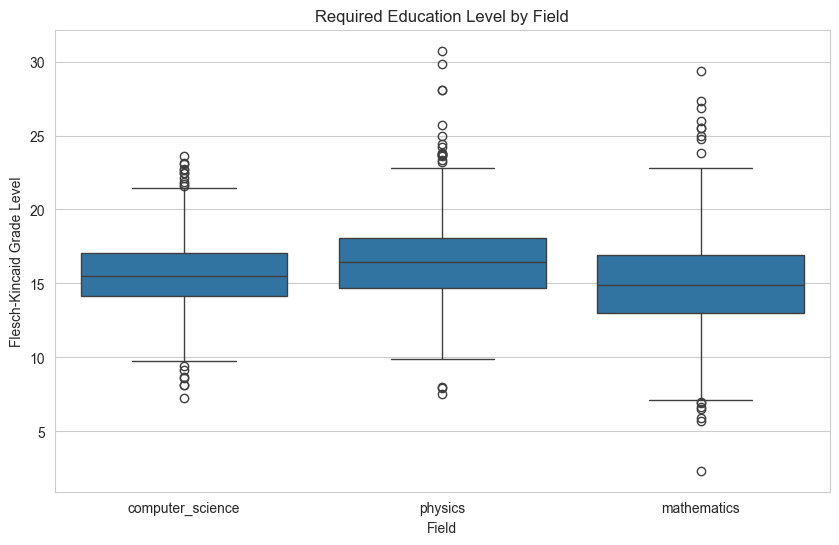

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="field", y="flesch_kincaid_grade")

plt.title("Required Education Level by Field")
plt.xlabel("Field")
plt.ylabel("Flesch-Kincaid Grade Level")

plt.show()

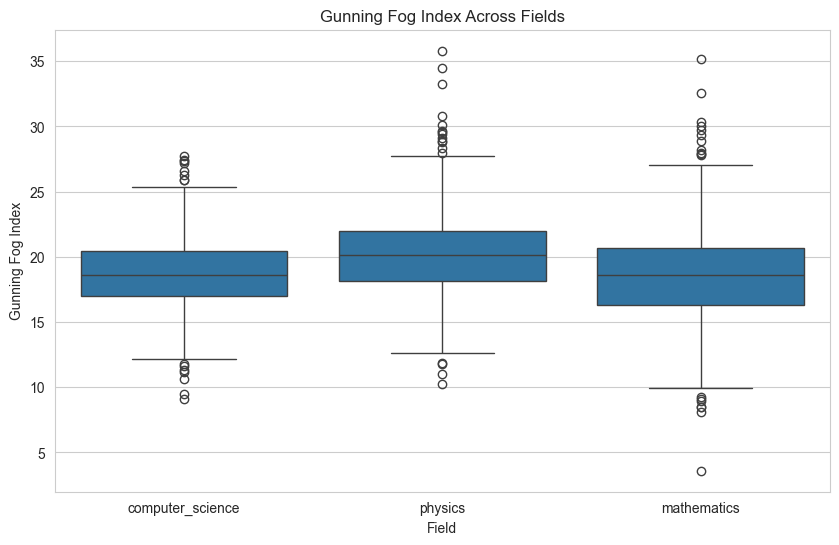

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="field", y="gunning_fog")

plt.title("Gunning Fog Index Across Fields")
plt.xlabel("Field")
plt.ylabel("Gunning Fog Index")

plt.show()

In [13]:
OUTPUT_PATH = "../data/processed/arxiv_with_readability.csv"

df.to_csv(OUTPUT_PATH, index=False)

print("Dataset saved with readability metrics.")

Dataset saved with readability metrics.
